## **0. Thiết lập môi trường và nạp dữ liệu**

In [1]:
# Nếu môi trường chưa có các thư viện dưới đây, bỏ comment dòng sau rồi chạy 1 lần:
# !pip install lightgbm shap scikit-learn scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import wilcoxon
import lightgbm as lgb
import shap

import warnings
warnings.filterwarnings("ignore")

sns.set_style("ticks")


In [2]:
df = pd.read_csv("SF_Tree_Maintenance_Daily_Data_Cleaned.csv", parse_dates=["date"])
df = df.sort_values(["nbhd", "date"]).reset_index(drop=True)

print(df.shape)
df.head()


(273224, 10)


,nbhd,date,n,permits_active,PRCP,AWND,TMAX,year,month,dow
0,Bayview Hunters Point,2008-07-01,0,0,0.0,4.6,19.4,2008,7,1
1,Bayview Hunters Point,2008-07-02,0,0,0.0,4.6,19.4,2008,7,2
2,Bayview Hunters Point,2008-07-03,0,0,0.0,4.6,19.4,2008,7,3
3,Bayview Hunters Point,2008-07-04,1,0,0.0,4.6,19.4,2008,7,4
4,Bayview Hunters Point,2008-07-05,0,0,0.0,4.6,19.4,2008,7,5


## **1. Xây dựng đặc trưng dự báo (Feature Engineering)**

In [3]:
# Biến mục tiêu: y_7d = tổng số ca bảo trì cây trong 7 NGÀY TỚI (dự báo tuần tới), tính riêng theo từng khu phố
# Dùng shift(-7) để "lùi lại" đúng 7 ngày trước khi tính rolling(7).sum() -- đảm bảo cửa sổ 7 ngày lấy ra
# là 7 ngày hoàn toàn SAU ngày hiện tại (i+1 đến i+7), không lẫn bất kỳ ngày nào thuộc quá khứ/hiện tại
def make_target(group):
    return group["n"].shift(-7).rolling(window=7, min_periods=7).sum()

df["y_7d"] = df.groupby("nbhd", group_keys=False).apply(make_target)

print("Số dòng có y_7d hợp lệ:", df["y_7d"].notna().sum(), "/", len(df))


Số dòng có y_7d hợp lệ: 272691 / 273224


In [4]:
# Đặc trưng trễ (lag) và trung bình trượt -- tính riêng theo từng khu phố để không rò rỉ dữ liệu giữa các khu phố
g = df.groupby("nbhd", group_keys=False)

df["n_lag1"]  = g["n"].shift(1)
df["n_lag7"]  = g["n"].shift(7)
df["n_lag14"] = g["n"].shift(14)
df["n_lag28"] = g["n"].shift(28)

df["n_ma7"]  = g["n"].apply(lambda s: s.shift(1).rolling(7).mean())
df["n_ma28"] = g["n"].apply(lambda s: s.shift(1).rolling(28).mean())

# Tổng 7 ngày gần nhất -- dùng làm đặc trưng cho mô hình Persistence ở bước sau
df["n_sum_past7"] = g["n"].apply(lambda s: s.shift(1).rolling(7).sum())

print("Đã tạo xong các đặc trưng trễ và trung bình trượt.")


Đã tạo xong các đặc trưng trễ và trung bình trượt.


In [5]:
# Mã hoá khu phố thành số để đưa vào mô hình cây (giữ nguyên cột nbhd dạng chữ để tra cứu sau)
df["nbhd_code"] = df["nbhd"].astype("category").cat.codes

# Loại bỏ các dòng đầu chuỗi (thiếu lag) và các dòng cuối chuỗi (thiếu target y_7d vì không đủ 7 ngày sau)
feature_cols_check = ["n_lag1", "n_lag7", "n_lag14", "n_lag28", "n_ma7", "n_ma28", "n_sum_past7", "y_7d"]
n0 = len(df)
feat = df.dropna(subset=feature_cols_check).reset_index(drop=True)
print(f"Đã bỏ {n0 - len(feat)} dòng thiếu đặc trưng trễ hoặc thiếu target (đầu/cuối mỗi khu phố).")
print("Số dòng còn lại để huấn luyện/kiểm thử:", feat.shape[0])


Đã bỏ 1435 dòng thiếu đặc trưng trễ hoặc thiếu target (đầu/cuối mỗi khu phố).
Số dòng còn lại để huấn luyện/kiểm thử: 271789


## **2. Chia tập huấn luyện và kiểm thử theo thời gian**

In [6]:
# Chia theo thời gian để tránh rò rỉ tương lai: huấn luyện đến hết 2023, kiểm thử từ 2024 trở đi
TRAIN_CUTOFF = "2024-01-01"
PURGE_DAYS = 7   # chừa 7 ngày để nhãn y_7d của train không nhìn sang test

train = feat[feat["date"] < pd.Timestamp(TRAIN_CUTOFF) - pd.Timedelta(days=PURGE_DAYS)].copy()
test  = feat[feat["date"] >= TRAIN_CUTOFF].copy()

print(f"Train: {train.shape[0]:,} dòng ({train['date'].min().date()} - {train['date'].max().date()})")
print(f"Test : {test.shape[0]:,} dòng ({test['date'].min().date()} - {test['date'].max().date()})")


Train: 230,707 dòng (2008-07-29 - 2023-12-24)
Test : 40,795 dòng (2024-01-01 - 2026-09-21)


In [7]:
X_cols = [
    "n_lag1", "n_lag7", "n_lag14", "n_lag28",
    "n_ma7", "n_ma28",
    "permits_active", "PRCP", "AWND", "TMAX",
    "dow", "month", "nbhd_code"
]
y_col = "y_7d"

X_train, y_train = train[X_cols], train[y_col]
X_test, y_test = test[X_cols], test[y_col]

print("Số đặc trưng sử dụng:", len(X_cols))


Số đặc trưng sử dụng: 13


## **3. Mô hình mốc (Baseline) -- Persistence và SeasonalNaive**

In [8]:
# Persistence: dự báo tuần tới = tổng 7 ngày gần nhất (giả định tuần sau giống tuần vừa qua)
pred_persistence = test["n_sum_past7"].values

mae_persistence = mean_absolute_error(y_test, pred_persistence)
print("MAE - Persistence:", round(mae_persistence, 3))


MAE - Persistence: 3.708


In [9]:
# SeasonalNaive: dự báo = tổng 7 ngày của CÙNG TUẦN NĂM TRƯỚC (lùi 364 ngày, giữ nguyên thứ trong tuần)
ly = df.set_index(["nbhd", "date"])["y_7d"]
keys = pd.MultiIndex.from_arrays([test["nbhd"], test["date"] - pd.Timedelta(days=364)])
test["y_7d_ly"] = ly.reindex(keys).values

valid_mask = test["y_7d_ly"].notna().values
mae_seasonal_naive = mean_absolute_error(test.loc[valid_mask, "y_7d"], test.loc[valid_mask, "y_7d_ly"])

print("MAE - SeasonalNaive:", round(mae_seasonal_naive, 3))
print("(Tính trên", valid_mask.sum(), "/", len(test), "dòng)")


MAE - SeasonalNaive: 4.351
(Tính trên 40795 / 40795 dòng)


## **4. Huấn luyện các mô hình học máy (5 seed mỗi mô hình để đo độ ổn định)**

In [10]:
SEEDS = [0, 1, 2, 3, 4]
results = []
CAT_COLS = ["dow", "month", "nbhd_code"]   # biến phân loại, không phải số thứ tự

def log_result(name, seed, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results.append({"model": name, "seed": seed, "MAE": mae, "RMSE": rmse,
                    "rMAE": mae / mae_persistence})


In [11]:
# Ridge -- cần chuẩn hoá dữ liệu trước (StandardScaler)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline

num_cols = [c for c in X_cols if c not in CAT_COLS]
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
ridge_model = make_pipeline(pre, Ridge(alpha=1.0))
ridge_model.fit(X_train, y_train)
log_result("Ridge", 0, y_test, ridge_model.predict(X_test))
print("Đã huấn luyện xong Ridge (mô hình tất định, chạy 1 lần).")


Đã huấn luyện xong Ridge (mô hình tất định, chạy 1 lần).


In [12]:
# Linear_OLS: hồi quy tuyến tính chỉ dùng đặc trưng trễ + lịch (không dùng permits/thời tiết)
lin_cols = ["n_lag1", "n_lag7", "n_lag14", "n_lag28", "n_ma7", "n_ma28", "dow", "month"]
lin_num = [c for c in lin_cols if c not in ["dow", "month"]]

pre_lin = ColumnTransformer([
    ("num", StandardScaler(), lin_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["dow", "month"]),
])
lin_model = make_pipeline(pre_lin, LinearRegression())
lin_model.fit(train[lin_cols], y_train)
log_result("Linear_OLS", 0, y_test, lin_model.predict(test[lin_cols]))
print("Đã huấn luyện xong Linear_OLS (mô hình tất định, chạy 1 lần).")


Đã huấn luyện xong Linear_OLS (mô hình tất định, chạy 1 lần).


In [13]:
# Random Forest
for seed in SEEDS:
    model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=seed, n_jobs=-1)
    model.fit(X_train, y_train)
    log_result("RandomForest", seed, y_test, model.predict(X_test))

print("Đã huấn luyện xong Random Forest với 5 seed.")


Đã huấn luyện xong Random Forest với 5 seed.


In [14]:
# LightGBM toàn cục (global model dùng chung cho tất cả khu phố, nbhd_code là 1 đặc trưng đầu vào)
lgb_params = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbosity=-1)
lgb_models = {}

for seed in SEEDS:
    model = lgb.LGBMRegressor(random_state=seed, **lgb_params)
    model.fit(X_train, y_train, categorical_feature=CAT_COLS)
    log_result("LightGBM_global", seed, y_test, model.predict(X_test))
    lgb_models[seed] = model

print("Đã huấn luyện xong LightGBM với 5 seed.")


Đã huấn luyện xong LightGBM với 5 seed.


## **5. So sánh các mô hình -- trả lời RQ2**

In [15]:
results_df = pd.DataFrame(results)

summary = results_df.groupby("model")[["MAE", "RMSE", "rMAE"]].agg(["mean", "std"]).round(3)

# Thêm 2 mốc so sánh (không chạy nhiều seed vì không có yếu tố ngẫu nhiên)
print(f"Persistence  MAE: {mae_persistence:.3f}")
print(f"SeasonalNaive MAE: {mae_seasonal_naive:.3f}")
print()
summary


Persistence  MAE: 3.708
SeasonalNaive MAE: 4.351



MAE          RMSE          rMAE       
                  mean    std   mean    std   mean    std
model                                                    
LightGBM_global  3.042  0.010  5.543  0.025  0.820  0.003
Linear_OLS       3.074    NaN  5.382    NaN  0.829    NaN
RandomForest     3.034  0.002  5.427  0.005  0.818  0.001
Ridge            2.965    NaN  5.351    NaN  0.800    NaN

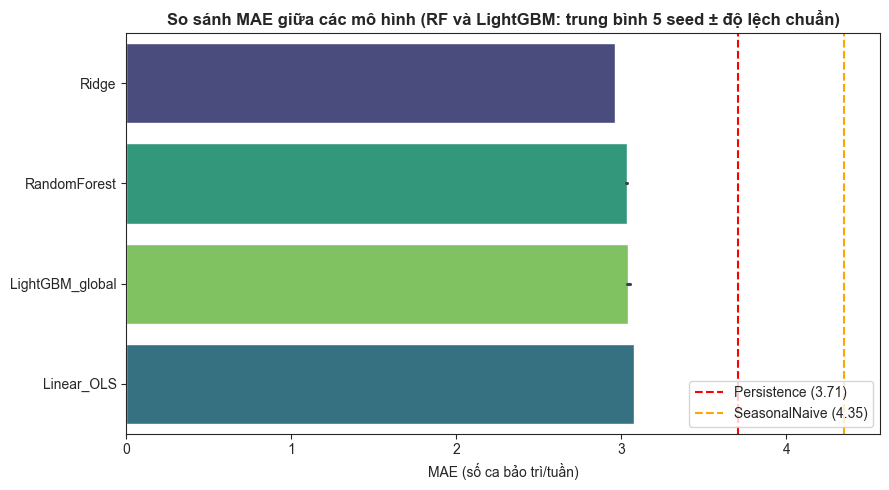

In [16]:
plt.figure(figsize=(9, 5))
order = results_df.groupby("model")["MAE"].mean().sort_values().index
sns.barplot(data=results_df, x="MAE", y="model", order=order, hue="model", palette="viridis", legend=False, errorbar="sd")
plt.axvline(mae_persistence, color="red", linestyle="--", label=f"Persistence ({mae_persistence:.2f})")
plt.axvline(mae_seasonal_naive, color="orange", linestyle="--", label=f"SeasonalNaive ({mae_seasonal_naive:.2f})")
plt.legend(loc="lower right")
plt.title("So sánh MAE giữa các mô hình (RF và LightGBM: trung bình 5 seed ± độ lệch chuẩn)", fontsize=12, fontweight="bold")
plt.xlabel("MAE (số ca bảo trì/tuần)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("fig_m01_model_comparison.png", dpi=300)
plt.show()


In [17]:
# So sánh mô hình tốt nhất (Ridge) với mô hình thứ 2 (RandomForest) trên cùng tập test
rf0 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf0.fit(X_train, y_train)

err = pd.DataFrame({
    "date": test["date"].values,
    "e_ridge": np.abs(y_test.values - ridge_model.predict(X_test)),
    "e_rf":    np.abs(y_test.values - rf0.predict(X_test)),
})
err["week"] = err["date"].dt.to_period("W")
wk = err.groupby("week")[["e_ridge", "e_rf"]].mean()   # sai số trung bình mỗi tuần (toàn bộ khu phố)

stat, pval = wilcoxon(wk["e_ridge"], wk["e_rf"])
print(f"Số tuần so sánh: {len(wk)}")
print(f"Ridge tốt hơn RF ở {(wk['e_ridge'] < wk['e_rf']).mean()*100:.1f}% số tuần")
print(f"Wilcoxon statistic = {stat:.1f}, p-value = {pval:.5f}")
print("--> Khác biệt có ý nghĩa thống kê" if pval < 0.05 else "--> Chưa đủ bằng chứng khác biệt có ý nghĩa thống kê")


Số tuần so sánh: 143
Ridge tốt hơn RF ở 58.7% số tuần
Wilcoxon statistic = 3753.0, p-value = 0.00494
--> Khác biệt có ý nghĩa thống kê


## **6. Kiểm tra khả năng tổng quát hoá -- rolling-origin và leave-neighbourhoods-out**

In [18]:
# Rolling-origin backtest: lặp lại việc chia train/test ở nhiều mốc thời gian
from sklearn.base import clone

cutoffs = ["2022-01-01", "2022-07-01", "2023-01-01", "2023-07-01", "2024-01-01"]
rolling_results = []

for cutoff in cutoffs:
    cut = pd.Timestamp(cutoff)
    tr = feat[feat["date"] < cut - pd.Timedelta(days=PURGE_DAYS)]
    te = feat[(feat["date"] >= cut) & (feat["date"] < cut + pd.DateOffset(months=6))]
    if len(te) == 0:
        continue

    lgb_m = lgb.LGBMRegressor(random_state=0, **lgb_params)
    lgb_m.fit(tr[X_cols], tr[y_col], categorical_feature=CAT_COLS)
    rdg = make_pipeline(clone(pre), Ridge(alpha=1.0)).fit(tr[X_cols], tr[y_col])

    rolling_results.append({
        "cutoff": cutoff,
        "so_dong_test": len(te),
        "MAE_Persistence": mean_absolute_error(te[y_col], te["n_sum_past7"]),
        "MAE_Ridge": mean_absolute_error(te[y_col], rdg.predict(te[X_cols])),
        "MAE_LightGBM": mean_absolute_error(te[y_col], lgb_m.predict(te[X_cols])),
    })

rolling_df = pd.DataFrame(rolling_results)
rolling_df["Ridge_thang_Persistence"] = rolling_df["MAE_Ridge"] < rolling_df["MAE_Persistence"]
rolling_df["LightGBM_thang_Persistence"] = rolling_df["MAE_LightGBM"] < rolling_df["MAE_Persistence"]
rolling_df.round(3)


,cutoff,so_dong_test,MAE_Persistence,MAE_Ridge,MAE_LightGBM,Ridge_thang_Persistence,LightGBM_thang_Persistence
0,2022-01-01,7421,2.852,2.250,2.274,True,True
1,2022-07-01,7544,2.270,2.070,2.173,True,True
2,2023-01-01,7421,4.772,3.724,3.643,True,True
3,2023-07-01,7544,2.943,2.301,2.257,True,True
4,2024-01-01,7462,3.828,2.878,2.936,True,True


In [19]:
# Leave-neighbourhoods-out: giữ lại từng nhóm khu phố, huấn luyện trên các khu còn lại,
# rồi so với mô hình đã được huấn luyện CÙNG những khu phố đó (so sánh trên cùng các dòng test)
X_cols_lno = [c for c in X_cols if c != "nbhd_code"]   # khu phố mới không có mã -> bỏ nbhd_code
cat_lno = ["dow", "month"]

cut = pd.Timestamp(TRAIN_CUTOFF)
pool = feat[feat["date"] < cut - pd.Timedelta(days=PURGE_DAYS)]
test_all = feat[feat["date"] >= cut]

# Mô hình tham chiếu: huấn luyện trên TẤT CẢ khu phố
ref = lgb.LGBMRegressor(random_state=0, **lgb_params)
ref.fit(pool[X_cols_lno], pool[y_col], categorical_feature=cat_lno)

nbhds = np.array(sorted(feat["nbhd"].unique()))
folds = np.array_split(np.random.default_rng(42).permutation(nbhds), 5)

rows = []
for k, hold in enumerate(folds, start=1):
    tr = pool[~pool["nbhd"].isin(hold)]
    te = test_all[test_all["nbhd"].isin(hold)]
    m = lgb.LGBMRegressor(random_state=0, **lgb_params)
    m.fit(tr[X_cols_lno], tr[y_col], categorical_feature=cat_lno)
    rows.append({
        "fold": k, "so_khu_giu_lai": len(hold), "so_dong_test": len(te),
        "MAE_Persistence": mean_absolute_error(te[y_col], te["n_sum_past7"]),
        "MAE_da_thay": mean_absolute_error(te[y_col], ref.predict(te[X_cols_lno])),
        "MAE_chua_thay": mean_absolute_error(te[y_col], m.predict(te[X_cols_lno])),
    })

lno_df = pd.DataFrame(rows)
lno_df["tang_pct"] = (lno_df["MAE_chua_thay"] / lno_df["MAE_da_thay"] - 1) * 100
print(lno_df.round(3).to_string())
print(f"MAE trung bình 5 fold - khu phố đã thấy : {lno_df['MAE_da_thay'].mean():.3f}")
print(f"MAE trung bình 5 fold - khu phố CHƯA thấy: {lno_df['MAE_chua_thay'].mean():.3f}")
print(f"Mức tăng sai số trung bình: {lno_df['tang_pct'].mean():+.1f}%")


   fold  so_khu_giu_lai  so_dong_test  MAE_Persistence  MAE_da_thay  MAE_chua_thay  tang_pct
0     1               9          8955            4.131        3.437          4.307    25.316
1     2               8          7960            3.820        3.205          3.233     0.892
2     3               8          7960            3.413        2.755          2.755     0.003
3     4               8          7960            3.107        2.691          2.750     2.179
4     5               8          7960            4.019        3.244          3.305     1.897
MAE trung bình 5 fold - khu phố đã thấy : 3.066
MAE trung bình 5 fold - khu phố CHƯA thấy: 3.270
Mức tăng sai số trung bình: +6.1%


In [20]:
# Khu phố nào nằm trong từng fold?
for k, hold in enumerate(folds, start=1):
    print(f"Fold {k}: {[str(x) for x in sorted(hold)]}")

# Chẩn đoán fold 1: sai số của từng khu phố bị giữ lại
hold1 = folds[0]
tr1 = pool[~pool["nbhd"].isin(hold1)]
m1 = lgb.LGBMRegressor(random_state=0, **lgb_params).fit(tr1[X_cols_lno], tr1[y_col], categorical_feature=cat_lno)

te1 = test_all[test_all["nbhd"].isin(hold1)].copy()
te1["err_persist"]   = np.abs(te1[y_col] - te1["n_sum_past7"])
te1["err_da_thay"]   = np.abs(te1[y_col] - ref.predict(te1[X_cols_lno]))
te1["err_chua_thay"] = np.abs(te1[y_col] - m1.predict(te1[X_cols_lno]))

te1.groupby("nbhd")[[y_col, "err_persist", "err_da_thay", "err_chua_thay"]].mean().round(2).sort_values(y_col, ascending=False)

Fold 1: ['Excelsior', 'Financial District/South Beach', 'Golden Gate Park', 'Marina', 'Mission', 'Outer Richmond', 'Seacliff', 'Visitacion Valley', 'Western Addition']
Fold 2: ['Inner Richmond', 'Nob Hill', 'Noe Valley', 'Outer Mission', 'Portola', 'Potrero Hill', 'Russian Hill', 'Tenderloin']
Fold 3: ['Glen Park', 'Hayes Valley', 'Inner Sunset', 'Oceanview/Merced/Ingleside', 'Pacific Heights', 'Presidio', 'Presidio Heights', 'Twin Peaks']
Fold 4: ['Bayview Hunters Point', 'Chinatown', 'Japantown', 'Lone Mountain/USF', 'McLaren Park', 'Mission Bay', 'North Beach', 'Sunset/Parkside']
Fold 5: ['Bernal Heights', 'Castro/Upper Market', 'Haight Ashbury', 'Lakeshore', 'Lincoln Park', 'South of Market', 'Treasure Island', 'West of Twin Peaks']


,y_7d,err_persist,err_da_thay,err_chua_thay
nbhd,,,,
Mission,30.16,11.04,9.40,17.61
Excelsior,8.83,4.79,3.62,3.72
Outer Richmond,8.81,4.42,3.43,3.44
Western Addition,8.24,4.60,3.65,3.65
Marina,8.15,3.99,3.40,3.16
Financial District/South Beach,5.55,3.42,3.18,2.90
Visitacion Valley,2.32,2.16,1.89,1.88
Golden Gate Park,1.77,1.80,1.51,1.54
Seacliff,0.78,0.96,0.84,0.85


In [21]:
te1_no_mission = te1[te1["nbhd"] != "Mission"]
for c in ["err_persist", "err_da_thay", "err_chua_thay"]:
    print(c, round(te1_no_mission[c].mean(), 3))

err_persist 3.267
err_da_thay 2.692
err_chua_thay 2.644


## **7. Độ tin cậy vận hành -- trả lời RQ3**

In [22]:
# Conformal prediction (split-conformal): dùng phần cuối tập train làm tập hiệu chuẩn
ALPHA = 0.10
val_cutoff = pd.Timestamp(TRAIN_CUTOFF) - pd.DateOffset(months=6)
cal_set = train[train["date"] >= val_cutoff]
fit_set = train[train["date"] < val_cutoff - pd.Timedelta(days=PURGE_DAYS)]   # chừa 7 ngày giữa fit và cal

model_best = lgb.LGBMRegressor(random_state=0, **lgb_params)
model_best.fit(fit_set[X_cols], fit_set[y_col], categorical_feature=CAT_COLS)

cal_pred = model_best.predict(cal_set[X_cols])
cal_res = pd.DataFrame({"nbhd": cal_set["nbhd"].values,
                        "res": np.abs(cal_set[y_col].values - cal_pred)})

def conf_q(r, alpha=ALPHA):
    n_ = len(r)
    level = min(1.0, np.ceil((n_ + 1) * (1 - alpha)) / n_)
    return np.quantile(r, level)

q_global = conf_q(cal_res["res"].values)                       # (A) một độ rộng chung
q_by_nbhd = cal_res.groupby("nbhd")["res"].apply(conf_q)       # (B) độ rộng riêng từng khu phố

test_pred_final = model_best.predict(X_test)
abs_err = np.abs(y_test.values - test_pred_final)
q_test_nb = test["nbhd"].map(q_by_nbhd).values

cover = pd.DataFrame({"nbhd": test["nbhd"].values,
                      "A_codinh": abs_err <= q_global,
                      "B_theo_khu": abs_err <= q_test_nb})
cov_nb = cover.groupby("nbhd")[["A_codinh", "B_theo_khu"]].mean()

lower = np.maximum(test_pred_final - q_test_nb, 0)   # số ca không âm
upper = test_pred_final + q_test_nb
avg_width = np.mean(upper - lower)

print(f"Mục tiêu bao phủ: {(1-ALPHA)*100:.0f}%")
print(f"(A) Độ rộng cố định ±{q_global:.2f}: coverage tổng = {cover['A_codinh'].mean()*100:.1f}% | khu thấp nhất = {cov_nb['A_codinh'].min()*100:.1f}% | số khu >= 85% = {(cov_nb['A_codinh']>=0.85).sum()}/{len(cov_nb)}")
print(f"(B) Theo từng khu phố:      coverage tổng = {cover['B_theo_khu'].mean()*100:.1f}% | khu thấp nhất = {cov_nb['B_theo_khu'].min()*100:.1f}% | số khu >= 85% = {(cov_nb['B_theo_khu']>=0.85).sum()}/{len(cov_nb)}")
print(f"Độ rộng trung bình khoảng (B): {avg_width:.2f}")
print("Coverage (B) của Mission:", round(cov_nb.loc["Mission", "B_theo_khu"] * 100, 1), "%")

Mục tiêu bao phủ: 90%
(A) Độ rộng cố định ±5.17: coverage tổng = 84.0% | khu thấp nhất = 43.0% | số khu >= 85% = 22/41
(B) Theo từng khu phố:      coverage tổng = 82.4% | khu thấp nhất = 60.6% | số khu >= 85% = 18/41
Độ rộng trung bình khoảng (B): 9.02
Coverage (B) của Mission: 78.3 %


In [23]:
# Cảnh báo "tuần nguy cơ cao": nhãn thật = y_7d vượt ngưỡng phân vị 90% của CHÍNH khu phố đó
# (ngưỡng chỉ tính trên tập train, không dùng thông tin từ test)
from sklearn.metrics import average_precision_score

thr_by_nbhd = train.groupby("nbhd")[y_col].quantile(0.90)

test_eval = test.copy()
test_eval["y_pred"] = test_pred_final
test_eval["threshold"] = test_eval["nbhd"].map(thr_by_nbhd)
test_eval["actual_high"] = test_eval[y_col] > test_eval["threshold"]
test_eval["predicted_high"] = test_eval["y_pred"] > test_eval["threshold"]

tp = (test_eval["actual_high"] & test_eval["predicted_high"]).sum()
fp = (~test_eval["actual_high"] & test_eval["predicted_high"]).sum()
fn = (test_eval["actual_high"] & ~test_eval["predicted_high"]).sum()
tn = (~test_eval["actual_high"] & ~test_eval["predicted_high"]).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
false_alarm = fp / (fp + tn)
pr_auc = average_precision_score(test_eval["actual_high"],
                                 test_eval["y_pred"] / np.maximum(test_eval["threshold"], 1))

print(f"Số khu phố có ngưỡng = 0: {(thr_by_nbhd == 0).sum()} / {len(thr_by_nbhd)}")
print(f"Tỷ lệ tuần 'nguy cơ cao' thật trong test: {test_eval['actual_high'].mean()*100:.1f}%  (định nghĩa trên train là 10%)")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1       : {f1:.3f}")
print(f"Tỷ lệ báo động giả: {false_alarm*100:.1f}%")
print(f"PR-AUC   : {pr_auc:.3f}")

Số khu phố có ngưỡng = 0: 3 / 41
Tỷ lệ tuần 'nguy cơ cao' thật trong test: 27.9%  (định nghĩa trên train là 10%)
Precision: 0.357
Recall   : 0.193
F1       : 0.250
Tỷ lệ báo động giả: 13.5%
PR-AUC   : 0.435


In [24]:
# Ablation: bỏ từng nhóm đặc trưng, đo MAE trên cùng tập test (5 seed, 2 cách chọn dữ liệu huấn luyện)
weather_cols = ["PRCP", "AWND", "TMAX"]
configs = {
    "Đầy đủ đặc trưng":  X_cols,
    "Bỏ permits_active": [c for c in X_cols if c != "permits_active"],
    "Bỏ thời tiết":      [c for c in X_cols if c not in weather_cols],
    "Bỏ đặc trưng lịch": [c for c in X_cols if c not in ["dow", "month"]],
}
windows = {
    "Train từ 2008 (như RQ2)": train,
    "Train từ 2015 (permits/thời tiết là dữ liệu thật)": train[train["date"] >= "2015-01-01"],
}

abl_rows = []
for wname, tr_w in windows.items():
    for cname, cols in configs.items():
        cats = [c for c in CAT_COLS if c in cols]
        for seed in SEEDS:
            m = lgb.LGBMRegressor(random_state=seed, **lgb_params)
            m.fit(tr_w[cols], tr_w[y_col], categorical_feature=cats)
            abl_rows.append({"train": wname, "config": cname, "seed": seed,
                             "MAE": mean_absolute_error(y_test, m.predict(test[cols]))})

abl = pd.DataFrame(abl_rows)
ablation_df = abl.groupby(["train", "config"])["MAE"].agg(["mean", "std"]).round(4).reset_index()
full_mae = ablation_df[ablation_df["config"] == "Đầy đủ đặc trưng"].set_index("train")["mean"]
ablation_df["thay_doi_pct"] = ((ablation_df["mean"] / ablation_df["train"].map(full_mae) - 1) * 100).round(2)

# Giữ lại các biến mà cell SHAP phía sau cần
model_full = lgb_models[0]
def get_mae(prefix, cfg):
    sel = ablation_df[(ablation_df["train"].str.startswith(prefix)) & (ablation_df["config"] == cfg)]
    return sel["mean"].iloc[0]
ablation_results = {cfg: get_mae("Train từ 2008", cfg) for cfg in configs}

ablation_df

,train,config,mean,std,thay_doi_pct
0,Train từ 2008 (như RQ2),Bỏ permits_active,3.0565,0.0060,0.48
1,Train từ 2008 (như RQ2),Bỏ thời tiết,3.0565,0.0098,0.48
2,Train từ 2008 (như RQ2),Bỏ đặc trưng lịch,3.0222,0.0074,-0.64
3,Train từ 2008 (như RQ2),Đầy đủ đặc trưng,3.0418,0.0098,0.00
4,Train từ 2015 (permits/thời tiết là dữ liệu thật),Bỏ permits_active,3.0536,0.0087,-0.06
5,Train từ 2015 (permits/thời tiết là dữ liệu thật),Bỏ thời tiết,3.0721,0.0056,0.54
6,Train từ 2015 (permits/thời tiết là dữ liệu thật),Bỏ đặc trưng lịch,3.0388,0.0076,-0.55
7,Train từ 2015 (permits/thời tiết là dữ liệu thật),Đầy đủ đặc trưng,3.0555,0.0086,0.00


## **8. Diễn giải mô hình bằng SHAP -- trả lời RQ4**

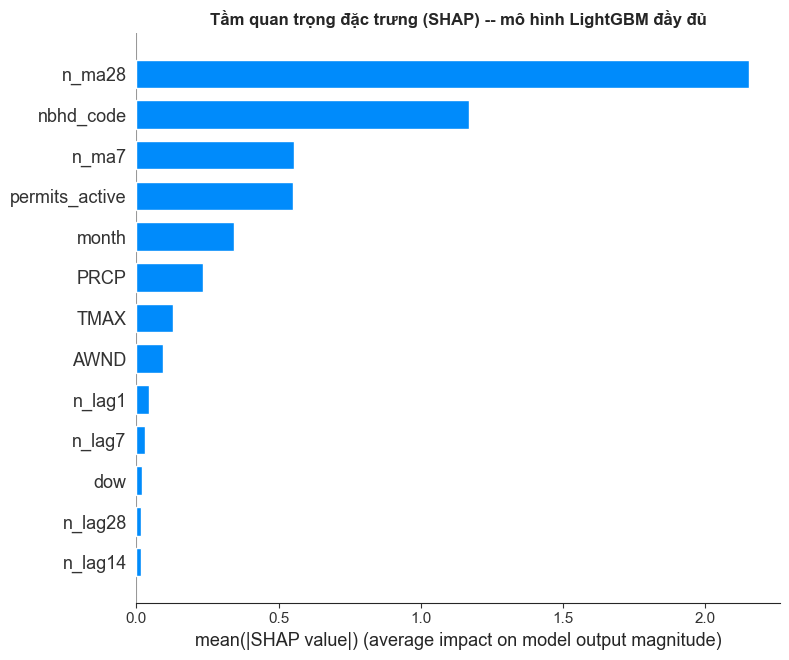

In [25]:
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X_test.sample(min(5000, len(X_test)), random_state=0))

shap.summary_plot(shap_values, X_test.sample(min(5000, len(X_test)), random_state=0), plot_type="bar", show=False)
plt.title("Tầm quan trọng đặc trưng (SHAP) -- mô hình LightGBM đầy đủ", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_m02_shap_importance.png", dpi=300)
plt.show()


In [26]:
# Kiểm tra giả thuyết RQ4: permits_active có đang "lặp lại" thông tin của khu phố / nhu cầu gần đây không?
tr15 = train[train["date"] >= "2015-01-01"]

# (a) Tương quan giữa permits_active và n_ma28 (nhu cầu gần đây)
rho_ma28 = tr15["permits_active"].corr(tr15["n_ma28"], method="spearman")

# (b) Giữa các khu phố: permits trung bình vs nhu cầu trung bình (41 điểm)
by_nb = tr15.groupby("nbhd")[["permits_active", y_col]].mean()
rho_between = by_nb["permits_active"].corr(by_nb[y_col], method="spearman")

# (c) Trong từng khu phố (đã trừ trung bình khu): permits còn liên quan tới nhu cầu không?
dm = tr15[["nbhd", "permits_active", y_col]].copy()
dm["permits_dm"] = dm["permits_active"] - dm.groupby("nbhd")["permits_active"].transform("mean")
dm["y_dm"] = dm[y_col] - dm.groupby("nbhd")[y_col].transform("mean")
rho_within = dm["permits_dm"].corr(dm["y_dm"], method="spearman")

print(f"(a) Spearman(permits_active, n_ma28): {rho_ma28:.3f}")
print(f"(b) Giữa các khu phố (41 khu, giá trị trung bình): {rho_between:.3f}")
print(f"(c) Trong từng khu phố (đã trừ trung bình khu): {rho_within:.3f}")

(a) Spearman(permits_active, n_ma28): 0.570
(b) Giữa các khu phố (41 khu, giá trị trung bình): 0.615
(c) Trong từng khu phố (đã trừ trung bình khu): 0.073


In [27]:
# Kết luận RQ4: tính từ số liệu, không viết sẵn
explainer = shap.TreeExplainer(model_full)
X_s = X_test.sample(3000, random_state=0)
sv = explainer.shap_values(X_s)
imp = pd.Series(np.abs(sv).mean(axis=0), index=X_cols).sort_values(ascending=False)
share = (imp / imp.sum() * 100).round(1)

rank_permits = list(imp.index).index("permits_active") + 1
diff_pct = (ablation_results["Bỏ permits_active"] / ablation_results["Đầy đủ đặc trưng"] - 1) * 100

print("5 đặc trưng quan trọng nhất (% tổng mean|SHAP|):")
print(share.head(5).to_string())
print()
print(f"permits_active: hạng {rank_permits}/{len(imp)} ({share['permits_active']}% tổng mức quan trọng)")
print(f"Ablation: bỏ permits_active làm MAE thay đổi {diff_pct:+.2f}%")
print(f"Spearman permits vs n_ma28: {rho_ma28:.3f} | giữa các khu: {rho_between:.3f} | trong từng khu: {rho_within:.3f}")
print()
if rank_permits <= 5 and abs(diff_pct) < 1:
    print("--> Nghịch lý RQ4 xuất hiện: permits xếp hạng cao nhưng bỏ đi không làm giảm độ chính xác.")
    if rho_between >= 0.5 and abs(rho_within) < 0.1:
        print("--> Phù hợp giả thuyết: permits chủ yếu phản ánh khu phố nào bận (thông tin đã có trong nbhd_code/n_ma28), không có thêm thông tin riêng.")
    else:
        print("--> Chưa đủ bằng chứng cho giả thuyết 'trùng lặp thông tin': cần kiểm tra thêm.")
else:
    print("--> Không xuất hiện nghịch lý RQ4 với số liệu hiện tại.")


5 đặc trưng quan trọng nhất (% tổng mean|SHAP|):
n_ma28            39.8
nbhd_code         22.2
permits_active    10.4
n_ma7             10.3
month              6.4

permits_active: hạng 3/13 (10.4% tổng mức quan trọng)
Ablation: bỏ permits_active làm MAE thay đổi +0.48%
Spearman permits vs n_ma28: 0.570 | giữa các khu: 0.615 | trong từng khu: 0.073

--> Nghịch lý RQ4 xuất hiện: permits xếp hạng cao nhưng bỏ đi không làm giảm độ chính xác.
--> Phù hợp giả thuyết: permits chủ yếu phản ánh khu phố nào bận (thông tin đã có trong nbhd_code/n_ma28), không có thêm thông tin riêng.


## **9. Khả năng thích ứng với thay đổi -- trả lời RQ5**

In [28]:
# RQ5: mô hình cố định (không cập nhật) vs mô hình tái huấn luyện hàng tháng
test_m = test.copy()
test_m["month_p"] = test_m["date"].dt.to_period("M")
test_m["pred_fixed"] = model_full.predict(test_m[X_cols])   # huấn luyện đến hết train, không cập nhật
test_m["pred_retrain"] = np.nan

for mp in sorted(test_m["month_p"].unique()):
    tr_m = feat[feat["date"] < mp.start_time - pd.Timedelta(days=PURGE_DAYS)]   # mọi dữ liệu đã biết trước tháng đó
    m = lgb.LGBMRegressor(random_state=0, **lgb_params)
    m.fit(tr_m[X_cols], tr_m[y_col], categorical_feature=CAT_COLS)
    idx = test_m["month_p"] == mp
    test_m.loc[idx, "pred_retrain"] = m.predict(test_m.loc[idx, X_cols])

rows = []
for mp, g in test_m.groupby("month_p"):
    rows.append({
        "month": str(mp),
        "MAE_Persistence": mean_absolute_error(g[y_col], g["n_sum_past7"]),
        "MAE_fixed":   mean_absolute_error(g[y_col], g["pred_fixed"]),
        "MAE_retrain": mean_absolute_error(g[y_col], g["pred_retrain"]),
        "bias_fixed":   (g["pred_fixed"] - g[y_col]).mean(),
        "bias_retrain": (g["pred_retrain"] - g[y_col]).mean(),
    })
rq5_df = pd.DataFrame(rows)
rq5_df["retrain_gain_pct"] = (1 - rq5_df["MAE_retrain"] / rq5_df["MAE_fixed"]) * 100

mae_fixed_all   = mean_absolute_error(test_m[y_col], test_m["pred_fixed"])
mae_retrain_all = mean_absolute_error(test_m[y_col], test_m["pred_retrain"])
stat, pval = wilcoxon(rq5_df["MAE_fixed"], rq5_df["MAE_retrain"])

print(f"Số tháng: {len(rq5_df)}")
print(f"MAE toàn test - cố định: {mae_fixed_all:.3f} | tái huấn luyện hàng tháng: {mae_retrain_all:.3f}")
print(f"Tái huấn luyện tốt hơn ở {(rq5_df['MAE_retrain'] < rq5_df['MAE_fixed']).mean()*100:.1f}% số tháng")
print(f"Sai lệch trung bình (dự báo - thực tế): cố định {rq5_df['bias_fixed'].mean():+.3f} | tái huấn luyện {rq5_df['bias_retrain'].mean():+.3f}")
print(f"Wilcoxon (so MAE theo tháng): p-value = {pval:.5f}")
rq5_df.round(3)


Số tháng: 33
MAE toàn test - cố định: 3.044 | tái huấn luyện hàng tháng: 2.965
Tái huấn luyện tốt hơn ở 72.7% số tháng
Sai lệch trung bình (dự báo - thực tế): cố định -1.391 | tái huấn luyện -1.019
Wilcoxon (so MAE theo tháng): p-value = 0.00277


,month,MAE_Persistence,MAE_fixed,MAE_retrain,bias_fixed,bias_retrain,retrain_gain_pct
0,2024-01,4.201,4.011,4.011,-1.265,-1.265,0.000
1,2024-02,8.609,4.894,4.811,-2.762,-2.807,1.706
2,2024-03,2.362,2.292,2.265,1.486,1.447,1.200
3,2024-04,2.427,1.975,1.975,-0.030,-0.034,0.002
4,2024-05,2.794,2.387,2.409,-0.235,-0.236,-0.910
5,2024-06,2.804,2.127,2.127,-0.117,-0.087,-0.004
6,2024-07,3.170,2.376,2.378,-0.538,-0.558,-0.058
7,2024-08,3.055,2.236,2.235,-0.557,-0.574,0.028
8,2024-09,2.689,2.082,2.076,-0.831,-0.822,0.262
9,2024-10,2.477,2.012,1.966,0.455,0.452,2.304


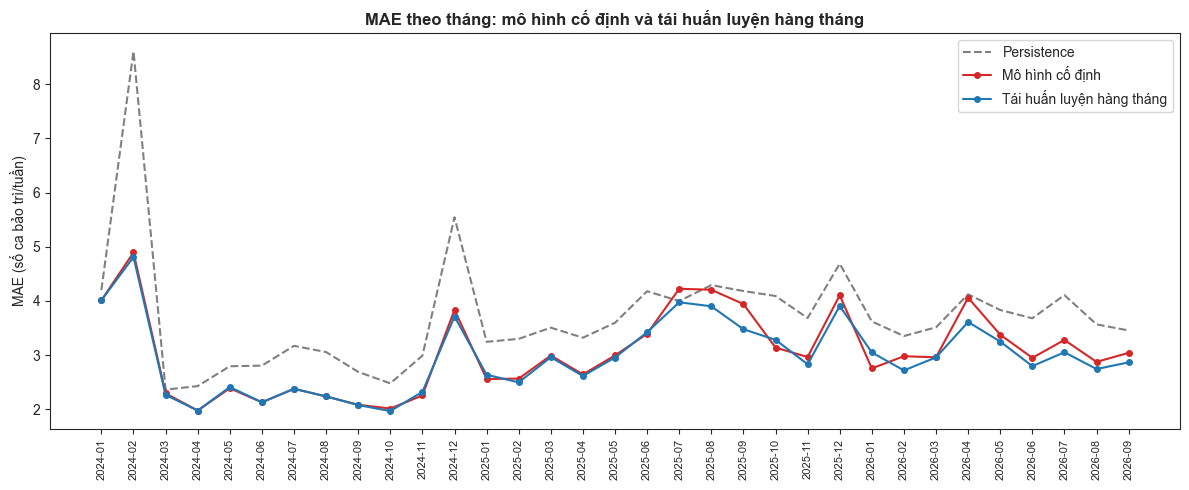

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(rq5_df["month"], rq5_df["MAE_Persistence"], color="gray", linestyle="--", label="Persistence")
plt.plot(rq5_df["month"], rq5_df["MAE_fixed"], color="tab:red", marker="o", markersize=4, label="Mô hình cố định")
plt.plot(rq5_df["month"], rq5_df["MAE_retrain"], color="tab:blue", marker="o", markersize=4, label="Tái huấn luyện hàng tháng")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("MAE (số ca bảo trì/tuần)")
plt.title("MAE theo tháng: mô hình cố định và tái huấn luyện hàng tháng", fontsize=12, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("fig_m03_monthly_mae.png", dpi=300)
plt.show()

In [30]:
gain = rq5_df["retrain_gain_pct"]
n_better = int((gain > 0.3).sum())
n_worse = int((gain < -0.3).sum())
n_tie = len(gain) - n_better - n_worse

print(f"MAE toàn test: cố định {mae_fixed_all:.3f} -> tái huấn luyện {mae_retrain_all:.3f} ({(1 - mae_retrain_all/mae_fixed_all)*100:.1f}% thấp hơn)")
print(f"Số tháng tái huấn luyện tốt hơn rõ (>0,3%): {n_better} | kém hơn rõ (<-0,3%): {n_worse} | xấp xỉ bằng nhau: {n_tie}")
print(f"Sai lệch trung bình (dự báo - thực tế): cố định {rq5_df['bias_fixed'].mean():+.3f} | tái huấn luyện {rq5_df['bias_retrain'].mean():+.3f}")
print(f"Wilcoxon (MAE theo tháng): p-value = {pval:.5f}")

MAE toàn test: cố định 3.044 -> tái huấn luyện 2.965 (2.6% thấp hơn)
Số tháng tái huấn luyện tốt hơn rõ (>0,3%): 20 | kém hơn rõ (<-0,3%): 6 | xấp xỉ bằng nhau: 7
Sai lệch trung bình (dự báo - thực tế): cố định -1.391 | tái huấn luyện -1.019
Wilcoxon (MAE theo tháng): p-value = 0.00277


## **10. Xuất bảng kết quả**

In [31]:
summary.to_csv("model_01_comparison_summary.csv")
ablation_df.to_csv("model_02_ablation.csv", index=False)
rq5_df.to_csv("model_03_retrain_comparison.csv", index=False)
rolling_df.to_csv("model_04_rolling_origin.csv", index=False)
lno_df.to_csv("model_05_leave_neighbourhoods_out.csv", index=False)
cov_nb.to_csv("model_06_conformal_coverage_by_nbhd.csv")
pd.DataFrame({
    "chi_so": ["precision", "recall", "f1", "false_alarm", "pr_auc", "ty_le_tuan_cao_thuc_te"],
    "gia_tri": [precision, recall, f1, false_alarm, pr_auc, test_eval["actual_high"].mean()],
}).to_csv("model_07_alert_metrics.csv", index=False)
share.rename("pct_mean_abs_shap").to_csv("model_08_shap_share.csv")

print("Đã lưu xong các bảng kết quả notebook 5.")


Đã lưu xong các bảng kết quả notebook 5.
